# Stochastic Simulation

This chapter covers
- the basics of stochastic simulation
- optimization for performance

Let's start by importing libraries we will need:

In [1]:
# %pip install numpy scipy numba line_profiler

# multiprocessing & progress
import joblib
import tqdm

import numpy as np
import scipy.stats as st
import numba

# plotting
import matplotlib.pyplot as plt
figsize = (5,4)

# profiler
%load_ext line_profiler

## Sampling traces from a CRN

Assume we are given a CRN and are interested to generate traces for this CRN.
This is also called sampling its CME exactly: if wwe would be repeating this process we would get closer and closer to the distribution of the CME.

Let us study how this can be done at the hand of our well known running example:

<div style="border-left:4px solid #4f7942; padding:1em 1.6em; margin:1.8em 0; border-radius:0 5px 5px 0;">

**Example: gene expression propensities**

Given a state $(m, p)$ for our gene expression system, we can write propensities as:

\begin{align}
\begin{array}{ll}
\text{reaction }r_i & \text{propensity } a_i \\
m \rightarrow m+1,\;\;\;\; & \beta_m \\[0.3em]
m \rightarrow m-1, \;\;\;\; & m\\[0.3em]
p \rightarrow p+1, \;\;\;\; & \beta_p m \\[0.3em]
p \rightarrow p-1, \;\;\;\; & \gamma p\enspace.
\end{array}
\end{align}


</div>

## Naive algorithm

For each reaction $r_i$, with $1 \leq i \leq k$, and propensity $a_i$ for reaction $r_i$, the time until its next occurrence, given no other reaction fires first, is

$$T_i \sim \text{Exp}(a_i).$$

Since the processes are independent, the first reaction to fire is

$$j = \arg\min_i T_i.$$

We apply the reaction to the current state and increment the time by $T_j$.
All other reaction times $T_i, i \neq j$ can be thrown away and be considered to not happen.
This is correct since the CRN is memoryless.

The process is repeated until some maximum simulation time or no reactions can fire anymore.

This scheme immediately gives a naive algorithm that **exactly samples the Chemical Master Equation (CME)**.
However, the **cost of $k$ exponential draws per step** can be improved as we will see in the next section.


## The Gillespie algorithm

Gillespie introduced and proved a simple and efficient algorithm that exactly samples the probability distribution described by the master equation; see [(Gillespie; Journal of Computational Physics, 1976)](https://doi.org/10.1016/0021-9991(76)90041-3) and [(Gillespie; The Journal of Physical Chemistry, 1977)](http://doi.org/10.1021/j100540a008).
We discuss this algorithm and a Python implementation in the following.



The idea of this improved algorithm is to split the question which reaction will be the first one and when it will happen into two separate questions.

####  Transition probabilities
The probability that the state change that happens because of reaction $j$ is proportional to $a_j$.
State changes with high propensities are more likely to occur.
Thus, choosing which of the $k$ state changes happens in $\Delta t$ can be determined by drawing an integer $j \in [1,k]$ where the probability of drawing $j$ is

\begin{align}
\frac{a_j}{\sum_i a_i}\enspace.
\end{align}


####  Transition times
Now, how do we determine how long the state change took?
From before, we know that

$$T_i(x) \sim \text{Exp}(a_i)$$

The probability density function $p_i$ for the stochastic variable $T_i$ thus is

\begin{align}
p_i(t) = a_i\, \mathrm{e}^{-a_i t}\enspace,
\end{align}

for $t \geq 0$, and $0$ otherwise.

The time $T(x)$ until the first reaction occurs in state $x$ is given by

$$T(x) = \min_{i} T_i(x).$$

One can show that

$$T(x) \sim \text{Exp}\left(\sum_i a_i\right).$$


### The algorithm
So, we know how to choose a state change and we also know how long it takes.
The Gillespie algorithm then proceeds as follows.

- Input: initial state $x$.
- Loop until done:
  - Calculate the propensity for each reaction depending on the current state $x$.
  - Compute how much time $\Delta$ the reaction will take by drawing out of an exponential distribution rate $\sum_i a_i$.
  - Compute which reaction will fire by drawing a sample out of the discrete distribution where $P_i = \left.a_i\middle/\left(\sum_i a_i\right)\right.$.
  - Increment time by $\Delta$ and update the states according to the reaction that fires.


## Implementing the Gillespie algorithm

To code up the Gillespie simulation, we first encode state updates as vectors, here for the running example:

In [2]:
from typing import TypedDict


class CRN(TypedDict):
    species: list[str]
    r_vec: np.ndarray
    state_update_vec: np.ndarray
    rate_constants: np.ndarray


species = ["mRNA", "protein"]

r_vec = np.array([
    [0, 0],  # DNA -> DNA + mRNA
    [1, 0],  # mRNA -> 0
    [1, 0],  # mRNA -> mRNA + protein
    [0, 1],  # protein -> 0
    ], dtype=int)

state_update_vec: np.ndarray = np.array(
    [
        [ 1,  0],  # DNA -> DNA + mRNA
        [-1,  0],  # mRNA -> 0
        [ 0,  1],  # mRNA -> mRNA + protein
        [ 0, -1],  # protein -> 0
    ],
    dtype=int,
)

rate_constants = np.array([0.5, 0.1, 0.2, 0.05], dtype=float)

example_crn: CRN = {
    "species": species,
    "r_vec": r_vec,
    "state_update_vec": state_update_vec,
    "rate_constants": rate_constants,
}


Next, propensities for the current state are returned via:

In [3]:
def update_propensity(
        propensities: np.ndarray,
        state: np.ndarray,
        r_vec: np.ndarray,
        rate_constants: np.ndarray) -> None:
    """Update the propensities for each reaction based on the current state.
    
    Attention: assumes that r_vec only contains 0, 1, and 2

    Parameters
    ----------
    propensities : np.ndarray
        Array to store the propensities for each reaction.
    state : np.ndarray
        Current state of the system (number of molecules of each species).
    r_vec : np.ndarray
        Reactant vector indicating how many molecules of each species are consumed by each reaction.
    rate_constants : np.ndarray
        Rate constants for each reaction.
    """
    propensities[:] = rate_constants * (
        np.where(r_vec >= 1, state, 1) * np.where(r_vec == 2, state - 1, 1)
    ).prod(axis=1)


### Time until reaction

First, to get the time until a reaction occurs, we sample a random number from an exponential distribution with rate parameter $\left(\sum_i a_i\right)$, i.e., mean $\left(\sum_i a_i\right)^{-1}$.
This can be done using the `np.random.exponential()` function.  

### Determine which reaction occurs

Next, we have to select which reaction will take place.  This amounts to drawing a sample over the discrete distribution where $P_i = a_i\left(\sum_i a_i\right)^{-1}$.
This can be done using `scipy.stats.rv_discrete`, which allows specification of an arbitrary discrete distribution.
We then use `rvs()` on this object to sample the distribution once.

In [4]:
def sample_discrete_scipy(probs: np.ndarray) -> int:
    """Randomly sample an index with probability given by probs.
    
    Parameters:
    ----------
    probs: np.ndarray
        An array of probabilities for each index. The probabilities must sum to 1."""
    return st.rv_discrete(values=(range(len(probs)), probs)).rvs()

This is a nice one-liner, but is it fast? There may be significant overhead in setting up the `scipy.stats` discrete random variable object to sample from each time. Remember, we can't just do this once because the array `probs` changes with each step in the SSA because the propensities change. We will therefore write a less elegant, but maybe faster way of doing it.  

Another way to sample the discrete distribution is to generate a uniformly distributed random number $q \sim \text{Uniform}(0,1)$ within bounds $0$ and $1$,
and return the value $j$ such that

\begin{align}
\sum_{i=0}^{j-1} p_i < q < \sum_{i=0}^{j}p_i.
\end{align}

We'll code this up.

In [5]:
def sample_discrete(probs: np.ndarray) -> int:
    """Randomly sample an index with probability given by probs."""
    # Generate random number
    q: float = np.random.rand()
    
    # Find index
    i: int = 0
    p_sum: float = 0.0
    while p_sum < q:
        p_sum += probs[i]
        i += 1
    return i - 1

Now let's compare the speeds using the `%timeit` function. This is a useful tool to help diagnose slow spots in your code.

In [6]:
# Make dummy probs
probs: np.ndarray = np.array([0.1, 0.3, 0.4, 0.05, 0.15])

print('Result from scipy.stats:')
%timeit sample_discrete_scipy(probs)

print('\nResult from plain Python method:')
%timeit sample_discrete(probs)

Result from scipy.stats:
180 μs ± 7.14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Result from plain Python method:
525 ns ± 11.3 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


The Python method is a couple of orders of magnitude faster - we will thus use it.

We next code a function that returns the two random draws we need for the Gillespie step.

In [7]:
def gillespie_draw(
        state: np.ndarray,
        propensities: np.ndarray,
        crn: CRN,
        ) -> tuple[int, float]:
    update_propensity(propensities, state, crn["r_vec"], crn["rate_constants"])
    props_sum = propensities.sum()
    delta = np.random.exponential(1.0 / props_sum)
    rxn = sample_discrete(propensities / props_sum)
    return rxn, delta


## Gillespie SSA implementation 

Now we are ready to write our main SSA loop.  We will only keep the counts at pre-specified time points. This saves on RAM, and we really only care about the values at given time points anyhow.

In [8]:
def gillespie_ssa(
        crn: CRN,
        initial_state: np.ndarray,
        output_times: np.ndarray,
        ) -> np.ndarray:
    update = crn["state_update_vec"]
    
    # allocate arrays
    output_states = np.empty((len(output_times), update.shape[1]), dtype=int)
    propensities = np.zeros(update.shape[0])

    i_time: int = 1
    i: int = 0

    # initial time, state, and output
    t = output_times[0]
    state = initial_state.copy()
    state_prev = state.copy()
    output_states[0, :] = state

    # event loop
    while i < len(output_times):
        while t < output_times[i_time]:
            # 2 random draws
            event, dt = gillespie_draw(state, propensities, crn)

            # update
            state_prev = state.copy()
            state += update[event, :]
            t += dt

        # passed an output time
        i = np.sum(output_times <= t)
        output_states[i_time : min(i, len(output_times))] = state_prev
        i_time = i
    return output_states


## Running and parsing results

We can now run a set of SSA simulations and plot the results.
We will run 100 trajectories.
We also use `tqdm` to give a progress bar so we know how long it is taking.

In [9]:
# simulation parameters
time_points = np.linspace(0, 200, 101)  # output times
initial_state = np.array([0, 0], dtype=int)  # initial counts
n_trajectories = 100  # number of trajectories to simulate

# seed random number generator for reproducibility
np.random.seed(42)

# allocate output array
samples = np.empty((n_trajectories, len(time_points), 2), dtype=int)

# run the simulations
for i in tqdm.tqdm(range(n_trajectories)):
    samples[i, :, :] = gillespie_ssa(
        example_crn,
        initial_state,
        time_points,
    )

100%|██████████| 100/100 [00:00<00:00, 205.74it/s]


We now have our samples, so we can plot the trajectories. For visualization, we will plot every trajectory as a thin blue line, and then the average of the trajectories as a thick orange line.

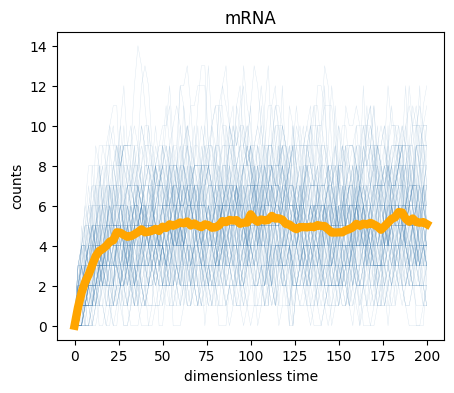

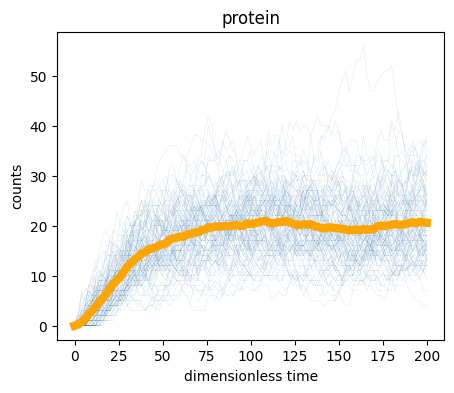

In [10]:
# Plot trajectories and mean
for i, name in enumerate(example_crn["species"]):
    plt.figure(figsize=figsize)
    plt.xlabel("dimensionless time")
    plt.ylabel("counts")
    plt.title(name)

    # plot species nr. i
    for species_values in samples[:, :, i]:
        plt.plot(
            time_points,
            species_values,
            lw=0.3,
            alpha=0.2,
            color="steelblue",
        )
    
    # plot mean
    plt.plot(
        time_points,
        samples[:, :, i].mean(axis=0),
        lw=6,
        color="orange",
    )

We can also compute the steady state properties by considering the end of the simulation.  The last 50 time points are at steady state, so we will average over them.

In [11]:
print("mRNA mean copy number =", samples[:, -50:, 0].mean())
print("protein mean copy number =", samples[:, -50:, 1].mean())

print("\nmRNA variance =", samples[:, -50:, 0].std() ** 2)
print("protein variance =", samples[:, -50:, 1].std() ** 2)

print("\nmRNA CV =", samples[:, -50:, 0].std() / samples[:, -50:, 0].mean())
print(
    "protein CV =", samples[:, -50:, 1].std() / samples[:, -50:, 1].mean()
)

mRNA mean copy number = 5.088
protein mean copy number = 20.0698

mRNA variance = 4.879856
protein variance = 45.29532796

mRNA CV = 0.43416659008027403
protein CV = 0.335338687029306


### Steady state
Finally, we can compute the steady state probability distributions.
To plot them, we plot the empirical probability density function (EPDF) from the sampling.

<div style="border-left:4px solid #4f7942; padding:1em 1.6em; margin:1.8em 0; border-radius:0 5px 5px 0;">

**Question: steady state**
Which steady state would you expect for mRNA and proteins from the ODE?
Once you have an answer, continue reading and let us check if they match.

</div>

A Poisson distribution with this mean has been overlayed for mRNA.

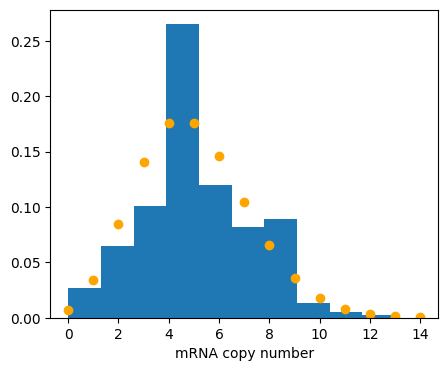

In [12]:
def epdf(vals: np.ndarray, xlabel: str) -> None:
    plt.xlabel(xlabel)
    plt.hist(vals, density=True)

# expected mean
beta_m = example_crn["rate_constants"][0]
gamma_m = example_crn["rate_constants"][1]
mrna_mean = beta_m / gamma_m

# empirical distribution
plt.figure(figsize=figsize)
epdf(samples[:, -50:, 0].flatten(), xlabel="mRNA copy number")
x = np.arange(int(mrna_mean * 3))

# expected distribution
plt.plot(x, st.poisson.pmf(x, mrna_mean), 'o', color="orange")

As we expect, the mRNA copy number matches a Poisson distribution with mean $\beta_m / \gamma_m$. You now have the basic tools for Gillespie simulations: define a CRN and an initial state, and call `gillespie_ssa`.


<hr>
**License & Attribution**: This page is from material by [Michael Elowitz and Justin Bois](https://biocircuits.github.io/) (© 2021–2025), licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/), with minor modifications.